**Week 6**<br />Wednesday, Oct. 7

# Classes

LX 394/694<br />
Coding for Linguists

Sophie Hao


## Announcements

- HW 1 solutions are available on Blackboard under Assignments!
- Grading will now commence on HW 1
- HW 2 will be released **Week 7** and due **Monday, October 26, 9 AM** (beginning of Week 9).
- You will use your HW 1 code to analyze US presidential speeches.

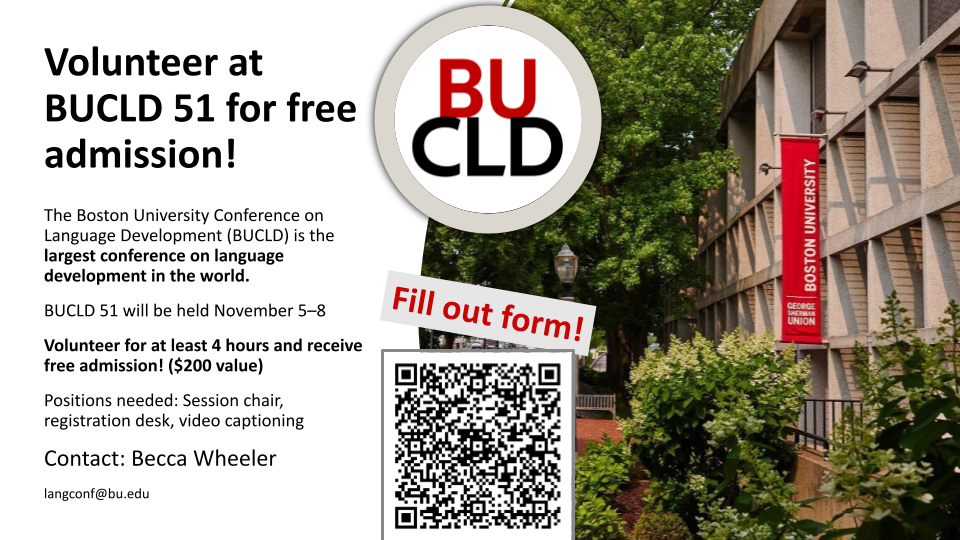

<a href="https://docs.google.com/forms/d/e/1FAIpQLSffK9w5w7DP82wj7OYOHfhJVGcPN3U1VVzrVHka1lapVN9IWg/viewform" style="color: #cccccc">Register to volunteer! (This is where the QR code links to)</a>

## Recap: NLTK-Specific Types

Recall that NLTK has custom types, that are not part of Python's built-in types. These include:
- `nltk.text.Text`
- `nltk.probability.FreqDist`, a special kind of `dict`

## Subclasses

When we say that "a `FreqDist` is a special kind of `dict`," what we mean that `FreqDist` is a **subclass** (or **subtype**) of `dict`.

In [1]:
from nltk.probability import FreqDist
from nltk.corpus import brown

brown_dist = FreqDist(brown.words())

In [2]:
# Is brown_dist a FreqDist?
isinstance(brown_dist, FreqDist)

True

In [3]:
# Is brown_dist a dict?
isinstance(brown_dist, dict)

True

## Inheritance

Because `FreqDist` is a subclass of `dict`, it inherits all the **methods** of `dict`. It also defines new methods.

In [5]:
# Treat a FreqDist like a dict
brown_dist["The"] = 50000000000000000
brown_dist

FreqDist({'The': 50000000000000000, 'the': 62713, ',': 58334, '.': 49346, 'of': 36080, 'and': 27915, 'to': 25732, 'a': 21881, 'in': 19536, 'that': 10237, ...})

In [6]:
# Treat a dict like a FreqDist...?
dict(brown_dist).most_common(10)

AttributeError: 'dict' object has no attribute 'most_common'

## FreqDist Class Definition

Python comes with a number of **built-in types** such as `int`, `float`, `str`, `list`, `dict`, etc.

Non-built-in types are defined using **classes**.

The **class definition** for `FreqDist` can be found in the [NLTK documentation](https://www.nltk.org/api/nltk.probability.FreqDist.html).

## Defining a Class

A class consists of...
- **methods:** functions associated with objects of that class's type
- **properties:** variables associated with objects of a class's type
- **constructor:** a method that tells you how to create objects of that class's type

The methods and properties of a class are collectively called **attributes**.

## Example: Class Definition

Let's say you were writing a [student information system](https://sites.bu.edu/sisrenewal/) for BU in Python.

In your app, each BU student would have a record containing all of their information. You could implement this by creating a new class called `Student`, such that each BU student would have their own `Student` object containing their records.

In [7]:
import statistics

class Student:
    """Student class definition"""
    
    def __init__(self, name: str):
        """Student class constructor"""
        self.name = name  # Student class properties
        self.grades = []
        
    # Student class methods
    def take_class(self, grade: float):
        self.grades.append(grade)
        
    def gpa(self) -> float:
        return statistics.mean(self.grades)

- **Methods:** `Student.__init__` (constructor), `Student.take_class`, `Student.gpa`
- **Properties:** `Student.name`, `Student.grades`

In [8]:
# Create a new student
romi = Student("Romi")

# What's this student's type?
print(f"Romi is a {type(romi)}.")

# What are this student's properties?
print(f"Name: {romi.name}, Grades: {romi.grades}")

Romi is a <class '__main__.Student'>.
Name: Romi, Grades: []


In [14]:
# Take some classes
romi.take_class(4.0)
romi.take_class(3.7)

# What's this student's GPA?
print(f"{romi.name}'s grades are {romi.grades}. Her GPA is...")
romi.gpa()

Romi's grades are [4.0, 3.7, 4.0, 3.7, 4.0, 3.7, 4.0, 3.7, 4.0, 3.7, 4.0, 3.7]. Her GPA is...


3.85

## Different Objects Have Different Properties

When you call `romi.gpa` (for example), the `romi` object gets passed to the method's `self` parameter. If you call the `.gpa` method from a different `Student` object, the result may be different, since you are using that `Student`'s properties instead of `romi`'s.

In [15]:
# Let's create a different student
dioan = Student("Dioan")
dioan.take_class(4.0)

# Look at the properties of each student
for s in [romi, dioan]:
    print(f"{s.name}'s GPA is {s.gpa()}")

Romi's GPA is 3.85
Dioan's GPA is 4.0


## Example: Subclass Definition

BU also has other types of people, like TFs and professors. All TFs are students, so it makes sense for TFs to be represented by a subclass of `Student`.

In [16]:
class Professor:
    def __init__(self, name: str, tenured: bool = False):
        self.name = name
        self.tenured = tenured

        
class TeachingFellow(Student):  # Make TeachingFellow a subclass of Student
    def __init__(self, name: str, prof: Professor):
        super().__init__(name)  # Call Student's constructor
        self.prof = prof

In [19]:
# Let's make Romi a TF
sophie = Professor("Sophie")
romi = TeachingFellow("Romi", sophie)
romi.prof.name

'Sophie'

In [22]:
# Romi still has all the attributes of a Student
romi.take_class(4.0)
romi.take_class(3.7)
romi.gpa()

3.85

## Example: Dict With Only String Keys

In [23]:
class StringDict(dict):  
    def __setitem__(self, key, value):  # This gets called when you run d[key] = value
        super().__setitem__(str(key), value)  # Call dict's __setitem__ method

In [24]:
d = StringDict()
d[1] = 2
d

{'1': 2}

## Next Time

Files